# B3 — Step 1: Data Download & Inspection

**Block:** B3 Symbol Detection (🟥 FULL)  
**Fine-tuning step:** 1 (Get the raw data) + start of 2 (Train/test split)

This notebook does **not** download data. You upload the three datasets to Google Drive
manually; this notebook **mounts Drive, verifies each dataset is present and structurally
intact, and runs label sanity-checks** — the checks your strategy doc calls the #1 cause of
fine-tuning failure.

### What B3 uses (per block spec §3)
| Dataset | Role for B3 | Expected on Drive |
|---|---|---|
| **Kaggle P&ID Symbols** | Pretrain (synthetic, 32-class boxes) | `kaggle_pid_symbols/` |
| **Gupta PID_Dataset** | Fine-tune + **test** (real, 72 train / 20 test) | `gupta_pid/` |
| **PID2Graph OPEN100** | *(B4/B7 — not B3, but validated here for completeness)* | `pid2graph/` |

> **Data discipline (spec §9):** the Gupta 20-sheet test split is touched exactly once, at
> final scoring. This notebook only *counts and inspects* it — it never opens test labels for
> any decision.

## 0. Configuration

Set `DRIVE_ROOT` to the folder where you uploaded the datasets. Adjust the three subfolder
names if yours differ. **Nothing else in the notebook needs editing.**

In [3]:
# --- Edit these to match your Drive layout ---
DRIVE_ROOT   = "/content/drive/MyDrive/pid_project/data"  # where you uploaded the datasets
KAGGLE_DIR   = "kaggle_pid_symbols"                        # subfolder: Kaggle P&ID Symbols
GUPTA_DIR    = "gupta_pid"                                 # subfolder: Gupta PID_Dataset
PID2GRAPH_DIR= "pid2graph"                                 # subfolder: PID2Graph OPEN100

# Data version tag (spec §1 fine-tuning: record which data every experiment used)
DATA_VERSION = "data-v1"

## 1. Mount Drive & install light deps

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Only lightweight libs — no model downloads at this stage
!pip -q install pillow numpy pandas 2>/dev/null

import os, json, glob, xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np, pandas as pd
from PIL import Image

ROOT = Path(DRIVE_ROOT)
print("Drive root:", ROOT, "| exists:", ROOT.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/pid_project/data | exists: True


## 1b. Install full dependency stack (Checklist 0.3)

Heavy/model deps — separate from the lightweight inspection libs above since these need
the GPU runtime. No MLflow (CLAUDE.md hard rule #8) — tracking is via `results.csv` +
`experiments/stage4/v*.md`.

Covers the Stage 4 base-VLM bake-off candidates (Qwen3-VL, InternVL3, Molmo).

In [5]:
%%capture install_log
!pip install -q \
    torch \
    transformers \
    accelerate \
    vllm \
    nvidia-cuda-runtime-cu13 \
    pycocotools \
    supervision \
    kagglehub \
    kaggle \
    qwen-vl-utils \
    einops \
    timm

### Kaggle API authentication

One-time setup (see instructions below the notebook) — save your Kaggle API token to
`{DRIVE_ROOT}/kaggle_access_token.txt` (just the raw token string, no quotes), then run
this cell to install it for the session as `~/.kaggle/access_token`.

In [5]:
with open(f"{DRIVE_ROOT}/kaggle_access_token.txt", "w") as f:
    f.write("KGAT_f7b679c152481eefca6f74c03bf4ec04")
print("saved")

saved


In [6]:
import os

token_src = f"{DRIVE_ROOT}/kaggle_access_token.txt"
kaggle_dir = os.path.expanduser("~/.kaggle")
token_dst = f"{kaggle_dir}/access_token"

if os.path.exists(token_src):
    os.makedirs(kaggle_dir, exist_ok=True)
    with open(token_src) as f:
        token = f.read().strip()
    with open(token_dst, "w") as f:
        f.write(token)
    os.chmod(token_dst, 0o600)
    print("Kaggle API token installed for this session.")
else:
    print(f"No token file found at {token_src} — see setup instructions, then re-run this cell.")

Kaggle API token installed for this session.


In [7]:
import glob
for d in ["/usr/local/lib/python3.12/dist-packages/nvidia/cuda_runtime/lib",
          "/usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib"]:
    print(d, "->", glob.glob(d + "/libcudart*"))

/usr/local/lib/python3.12/dist-packages/nvidia/cuda_runtime/lib -> ['/usr/local/lib/python3.12/dist-packages/nvidia/cuda_runtime/lib/libcudart.so.12']
/usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib -> ['/usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libcudart_static.a', '/usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libcudart.so.13']


In [8]:
# --- ✓ Confirm: every package imports without error; print versions; pin requirements.txt ---
import importlib, os, glob, sys, ctypes

# LD_LIBRARY_PATH set at runtime doesn't reliably reach later dlopen() calls, so preload
# libcudart.so.13 directly via ctypes before importing vllm.
cudart_paths = []
for sp in sys.path:
    cudart_paths += glob.glob(f"{sp}/nvidia/*/lib/libcudart.so.13")

if cudart_paths:
    ctypes.CDLL(cudart_paths[0], mode=ctypes.RTLD_GLOBAL)
    print("Preloaded:", cudart_paths[0])
else:
    print("WARNING: libcudart.so.13 not found under any nvidia/*/lib in sys.path")

packages = [
    "torch", "transformers", "accelerate", "vllm", "pycocotools",
    "supervision", "kagglehub", "kaggle", "qwen_vl_utils", "einops", "timm",
]

failed = []
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        print(f"{pkg:15s} OK  {getattr(mod, '__version__', 'version n/a')}")
    except Exception as e:
        print(f"{pkg:15s} FAILED: {e}")
        failed.append(pkg)

if failed:
    print("\nFAILED packages:", failed)
else:
    # Pin exact versions to Drive so the environment is reproducible
    req_path = f"{DRIVE_ROOT}/requirements.txt"
    !pip freeze > "{req_path}"
    print("\nrequirements.txt saved to:", req_path)


Preloaded: /usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libcudart.so.13
torch           OK  2.11.0+cu128
transformers    OK  5.12.1
accelerate      OK  1.14.0
vllm            OK  0.24.0
pycocotools     OK  version n/a
supervision     OK  0.29.1
kagglehub       OK  1.0.2
kaggle          OK  2.0.2
qwen_vl_utils   OK  version n/a
einops          OK  0.8.2
timm            OK  1.0.27

requirements.txt saved to: /content/drive/MyDrive/pid_project/data/requirements.txt


## 2. Presence check — are the three datasets where we expect them?

Fails loudly with a clear message if a folder is missing, so you fix the upload before wasting
a session.

In [9]:
def check_dir(name, sub):
    p = ROOT / sub
    ok = p.exists() and any(p.iterdir()) if p.exists() else False
    status = "✅" if ok else "❌"
    n_files = sum(1 for _ in p.rglob('*') if _.is_file()) if p.exists() else 0
    print(f"{status}  {name:12s} → {p}  ({n_files} files)")
    return p, ok

kaggle_p,  kaggle_ok  = check_dir("Kaggle",    KAGGLE_DIR)
gupta_p,   gupta_ok   = check_dir("Gupta",     GUPTA_DIR)
p2g_p,     p2g_ok     = check_dir("PID2Graph", PID2GRAPH_DIR)

if not (kaggle_ok and gupta_ok):
    print("\n⚠️  B3 needs Kaggle (pretrain) + Gupta (fine-tune/test). Fix uploads before continuing.")
else:
    print("\nB3-required datasets present. PID2Graph is optional for B3.")

✅  Kaggle       → /content/drive/MyDrive/pid_project/data/kaggle_pid_symbols  (36595 files)
✅  Gupta        → /content/drive/MyDrive/pid_project/data/gupta_pid  (5526 files)
✅  PID2Graph    → /content/drive/MyDrive/pid_project/data/pid2graph  (68083 files)

B3-required datasets present. PID2Graph is optional for B3.


## 3. Explore folder structure

Datasets ship with different layouts; print a shallow tree so we can see how each is organised
before hard-coding paths.

In [17]:
def shallow_tree(root, max_depth=2, max_entries=12, _depth=1):
    root = Path(root)
    if _depth == 1 and not root.exists():
        print(f"(missing) {root}"); return
    try:
        entries = sorted(root.iterdir())
    except NotADirectoryError:
        return
    shown = entries[:max_entries]
    indent = "  " * (_depth - 1)
    for p in shown:
        tag = "/" if p.is_dir() else ""
        print(f"{indent}{p.name}{tag}")
        if p.is_dir() and _depth < max_depth:
            shallow_tree(p, max_depth, max_entries, _depth + 1)
    if len(entries) > max_entries:
        print(f"{indent}... ({len(entries) - max_entries} more)")

for label, p, ok in [("KAGGLE", kaggle_p, kaggle_ok), ("GUPTA", gupta_p, gupta_ok), ("PID2GRAPH", p2g_p, p2g_ok)]:
    print(f"\n===== {label} =====")
    if ok: shallow_tree(p)
    else:  print("(not present)")


===== KAGGLE =====
images/
  0_0_0.jpg
  0_0_1280.jpg
  0_0_1920.jpg
  0_0_2560.jpg
  0_0_3200.jpg
  0_0_3840.jpg
  0_0_4480.jpg
  0_0_5120.jpg
  0_0_5760.jpg
  0_0_640.jpg
  0_1280_0.jpg
  0_1280_1280.jpg
  ... (29988 more)
labels/
  0_1280_1920.txt
  0_1280_4480.txt
  0_1280_5760.txt
  0_1280_640.txt
  0_1920_5120.txt
  0_1920_640.txt
  0_2560_1280.txt
  0_2560_2560.txt
  0_3200_3840.txt
  0_3200_4480.txt
  0_3200_5760.txt
  0_640_5120.txt
  ... (6579 more)
train (1).txt
train (2).txt
train.txt
val.txt

===== GUPTA =====
PID_Dataset/
  0__raw_data/
  1__processed_data/
  2__Stage-1/
  3__Stage-2/
  Readme.txt

===== PID2GRAPH =====
PID2Graph/
  Complete/
  Patched/


In [18]:
shallow_tree(gupta_p / "PID_Dataset" / "2__Stage-1", max_depth=2)
print()
shallow_tree(gupta_p / "PID_Dataset" / "3__Stage-2", max_depth=2)

1__Pretrained_models/
  1_Scratch/
  2_ Finetune_on_MS_COCO/
  3_Transfer_Learning_from_Imagenet/
  4_Transfer_Learning_from_Omniglot/
  train.txt
  val.txt
2__Sampling_methods/
  1__Random_sampling/
  2__Coreset_sampling/
3__Psuedolabels/
  Itr_0/
  Itr_1/
  Itr_2/
  Itr_3/
  Itr_4/
  Itr_5/
  Itr_6/
  Itr_7/
  Itr_8/

.ipynb_checkpoints/
  Siamese_network_with_Triplet_loss-checkpoint.ipynb
1_1__Train_data/
  anchor/
1_2__Trained_Weights/
  triplet_30_v1.pth
1_Siamese_network_model_architecture_Train.ipynb
2_Siamese_network_with_Triplet_loss_model_Inference.ipynb
2__Test_data/
  100_classes_data_sheets_wise/


In [19]:
shallow_tree(gupta_p / "PID_Dataset" / "0__raw_data", max_depth=2, max_entries=20)
print()
shallow_tree(gupta_p / "PID_Dataset" / "1__processed_data", max_depth=2, max_entries=20)

labels/
  classes.txt
  test/
  train/
sheets/
  test/
  train/

crops/
  test/
  train/
labels/
  Classes.txt
  test/
  train/


In [20]:
train_sheets = list((gupta_p / "PID_Dataset" / "0__raw_data" / "sheets" / "train").iterdir())
test_sheets  = list((gupta_p / "PID_Dataset" / "0__raw_data" / "sheets" / "test").iterdir())

print(f"train sheets: {len(train_sheets)}")
print(f"test sheets:  {len(test_sheets)}")
print(f"total:        {len(train_sheets) + len(test_sheets)}")

assert len(train_sheets) == 72, f"expected 72 train sheets, got {len(train_sheets)}"
assert len(test_sheets) == 20, f"expected 20 test sheets, got {len(test_sheets)}"
print("\n✓ 92-sheet split confirmed (72 train / 20 test)")

train sheets: 72
test sheets:  20
total:        92

✓ 92-sheet split confirmed (72 train / 20 test)


## 4. Kaggle P&ID Symbols — inspect (pretrain source)

Expected per spec: ~500 diagrams, ~30k tiles, **32-class** boxes, ~195k instances.
We auto-detect the annotation format (Pascal VOC XML / YOLO txt / COCO json) and report the
**class distribution** — imbalance here directly informs pretraining (strategy step 8.3).

In [26]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def scan_tree(root):
    """Single os.walk pass — avoids repeated rglob() re-walks over slow Drive FUSE mounts."""
    root = Path(root)
    n_images = 0
    xml_files, json_files = [], []
    label_txt_files = []
    names_file = None
    for dirpath, dirnames, filenames in os.walk(root):
        dp = Path(dirpath)
        in_labels_dir = 'labels' in dp.parts
        for fn in filenames:
            ext = os.path.splitext(fn)[1].lower()
            if ext in IMAGE_EXTS:
                n_images += 1
            elif ext == '.xml':
                xml_files.append(dp / fn)
            elif ext == '.json':
                json_files.append(dp / fn)
            elif ext == '.txt':
                if fn.lower() in ('classes.txt', 'names.txt'):
                    names_file = dp / fn
                elif in_labels_dir:
                    label_txt_files.append(dp / fn)
    fmts = []
    if xml_files: fmts.append('voc_xml')
    if label_txt_files: fmts.append('yolo_txt?')
    if json_files: fmts.append('coco_json?')
    return {
        'n_images': n_images, 'fmts': fmts,
        'xml_files': xml_files, 'json_files': json_files,
        'label_txt_files': label_txt_files, 'names_file': names_file,
    }

def yolo_class_histogram(label_txt_files, max_workers=32):
    """Read label files concurrently — I/O-bound over Drive FUSE, so threads help a lot."""
    from concurrent.futures import ThreadPoolExecutor

    def read_ids(txt):
        ids = []
        for line in txt.read_text().splitlines():
            line = line.strip()
            if line:
                ids.append(line.split()[0])
        return ids

    counts = Counter()
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for ids in ex.map(read_ids, label_txt_files):
            counts.update(ids)
    return counts

def voc_class_histogram(xml_files):
    counts = Counter()
    for x in xml_files:
        try:
            for obj in ET.parse(x).getroot().findall('.//object'):
                nm = obj.findtext('name')
                if nm: counts[nm] += 1
        except Exception:
            pass
    return counts

if kaggle_ok:
    scan = scan_tree(kaggle_p)
    print("Detected annotation formats:", scan['fmts'])
    print("Image count:", scan['n_images'])

    if 'yolo_txt?' in scan['fmts']:
        counts = yolo_class_histogram(scan['label_txt_files'])
        if counts:
            print(f"\nParsed {len(scan['label_txt_files'])} YOLO label files, {sum(counts.values())} instances, {len(counts)} classes")
            if scan['names_file']:
                names = [l.strip() for l in scan['names_file'].read_text().splitlines() if l.strip()]
                class_names = {i: n for i, n in enumerate(names)}
                print(f"Class names loaded from: {scan['names_file']}")
                rows = [(class_names.get(int(cid), cid), n) for cid, n in counts.items()]
            else:
                print("No classes.txt/names.txt found — reporting raw class indices.")
                rows = list(counts.items())
            df = pd.DataFrame(sorted(rows, key=lambda r: -r[1]), columns=['class', 'count'])
            display(df)
            print("Rarest 5 classes (few-shot / Siamese candidates):")
            print(df.tail(5).to_string(index=False))
        else:
            print("\nNo YOLO label lines parsed — inspect the tree above; check labels/ folder contents.")
    elif scan['xml_files']:
        class_counts = voc_class_histogram(scan['xml_files'])
        if class_counts:
            print(f"\nParsed {len(scan['xml_files'])} XML files, {sum(class_counts.values())} instances, {len(class_counts)} classes")
            df = pd.DataFrame(class_counts.most_common(), columns=['class','count'])
            display(df)
            print("Rarest 5 classes (few-shot / Siamese candidates):")
            print(df.tail(5).to_string(index=False))
        else:
            print("\nNo VOC objects parsed — inspect the tree above; format may be COCO. Tell me and I'll add a parser.")
    else:
        print("\nNo XML/YOLO annotations found — inspect the tree above; format may be COCO. Tell me and I'll add a parser.")
else:
    print("Kaggle not present — skipping.")

Detected annotation formats: ['yolo_txt?']
Image count: 30000

Parsed 6591 YOLO label files, 43055 instances, 32 classes
No classes.txt/names.txt found — reporting raw class indices.


,class,count
0,21,3832
1,25,1407
2,12,1391
3,16,1390
4,6,1360
5,2,1344
6,3,1327
7,20,1316
8,5,1311
9,13,1306


Rarest 5 classes (few-shot / Siamese candidates):
class  count
    7   1200
   32   1189
   29   1179
   30   1166
   26   1120


In [16]:
for pat in ('*.yaml', '*.yml', 'README*', 'readme*'):
    hits = list(kaggle_p.rglob(pat))
    if hits:
        print(pat, '->', hits)

## 5. Gupta PID_Dataset — inspect (fine-tune + TEST source)

Expected per spec: 92 real sheets (**72 train / 20 test**), class-agnostic "Symbol" boxes.
This is the real judging set for B3, so we verify the split counts and confirm the
class-agnostic labelling (which is what pushes the fixed-head-vs-Siamese question).

In [17]:
if gupta_ok:
    raw = gupta_p / "PID_Dataset" / "0__raw_data"
    scan = scan_tree(raw)
    print("Detected annotation formats:", scan['fmts'])
    print("Total images:", scan['n_images'])

    print("\nSheets — train:", len(list((raw / 'sheets' / 'train').iterdir())),
          "| test:", len(list((raw / 'sheets' / 'test').iterdir())))

    classes_file = raw / "labels" / "classes.txt"
    if classes_file.exists():
        class_names = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
        print(f"classes.txt: {class_names}")

    # Class-agnostic check: collect distinct label names/ids across train+test label files
    labels = Counter()
    if 'yolo_txt?' in scan['fmts'] and scan['label_txt_files']:
        for txt in scan['label_txt_files']:
            for line in txt.read_text().splitlines():
                line = line.strip()
                if line:
                    labels[line.split()[0]] += 1
    elif scan['xml_files']:
        for x in scan['xml_files']:
            try:
                for obj in ET.parse(x).getroot().findall('.//object'):
                    nm = obj.findtext('name')
                    if nm: labels[nm] += 1
            except Exception:
                pass

    if labels:
        print(f"\nDistinct label values in Gupta: {len(labels)}")
        print(dict(labels.most_common(10)))
        if len(labels) <= 3:
            print("→ Confirms class-agnostic 'Symbol' labelling (localization GT only, not typing).")
    else:
        print("No labels parsed under 0__raw_data — check tree; report back.")
else:
    print("Gupta not present — skipping.")

Detected annotation formats: ['yolo_txt?']
Total images: 92

Sheets — train: 72 | test: 20
classes.txt: ['Symbol']

Distinct label values in Gupta: 1
{'0': 4302}
→ Confirms class-agnostic 'Symbol' labelling (localization GT only, not typing).


## 6. Image health check

Corrupt/unreadable images and wildly inconsistent resolutions are silent fine-tuning killers.
Sample a subset from each dataset and report readability + size distribution.

In [21]:
def image_health(files, sample=40):
    if not files:
        print("  no images found"); return
    import random; random.seed(0)
    sub = random.sample(files, min(sample, len(files)))
    sizes, bad = [], 0
    for f in sub:
        try:
            with Image.open(f) as im: sizes.append(im.size)
        except Exception:
            bad += 1
    if sizes:
        ws, hs = zip(*sizes)
        print(f"  sampled {len(sub)} | unreadable: {bad}")
        print(f"  width  min/med/max: {min(ws)}/{int(np.median(ws))}/{max(ws)}")
        print(f"  height min/med/max: {min(hs)}/{int(np.median(hs))}/{max(hs)}")

def list_images(root):
    exts = IMAGE_EXTS
    return [Path(dp) / fn for dp, _, fns in os.walk(root) for fn in fns if os.path.splitext(fn)[1].lower() in exts]

for label, p, ok in [("KAGGLE", kaggle_p, kaggle_ok), ("GUPTA", gupta_p, gupta_ok)]:
    print(f"{label}:")
    if ok: image_health(list_images(p))
    else:  print("  (not present)")
    print()

KAGGLE:
  sampled 40 | unreadable: 0
  width  min/med/max: 1280/1280/1280
  height min/med/max: 1280/1280/1280

GUPTA:
  sampled 40 | unreadable: 0
  width  min/med/max: 224/224/416
  height min/med/max: 224/224/416



## 6b. Annotation integrity check (Checklist 1.5)

Zero orphan annotations (label file with no matching image) and zero unannotated
images within each labeled split. Matched by filename stem.

In [24]:
def stems(files):
    return {Path(f).stem for f in files}

def report_integrity(name, image_stems, label_stems):
    orphans = label_stems - image_stems
    unannotated = image_stems - label_stems
    print(f"{name}: images={len(image_stems)} labels={len(label_stems)} "
          f"orphans={len(orphans)} unannotated={len(unannotated)}")
    return orphans, unannotated

results = {}

# --- Kaggle: flat images/ + labels/ ---
if kaggle_ok:
    kaggle_images = list_images(kaggle_p / "images")
    kaggle_labels = list((kaggle_p / "labels").glob("*.txt"))
    orphans, unannotated = report_integrity(
        "KAGGLE", stems(kaggle_images), stems(kaggle_labels)
    )
    results['kaggle'] = (orphans, unannotated)
    if unannotated:
        # cross-check against train.txt/val.txt — some images may be intentionally
        # excluded from the labeled split rather than a real mismatch
        listed = set()
        for lst in ('train.txt', 'val.txt'):
            f = kaggle_p / lst
            if f.exists():
                for line in f.read_text().splitlines():
                    line = line.strip()
                    if line:
                        listed.add(Path(line).stem)
        unannotated_but_listed = unannotated & listed
        print(f"  of {len(unannotated)} unannotated, {len(unannotated_but_listed)} are in train.txt/val.txt (real mismatch)")
        print(f"  remaining {len(unannotated) - len(unannotated_but_listed)} are outside the listed split (likely intentional negatives)")

# --- Gupta: sheets/{train,test} + labels/{train,test} ---
if gupta_ok:
    raw = gupta_p / "PID_Dataset" / "0__raw_data"
    for split in ('train', 'test'):
        sheet_imgs = list_images(raw / "sheets" / split)
        label_txts = list((raw / "labels" / split).glob("*.txt"))
        orphans, unannotated = report_integrity(
            f"GUPTA/{split}", stems(sheet_imgs), stems(label_txts)
        )
        results[f'gupta_{split}'] = (orphans, unannotated)

print()
for name, (orphans, unannotated) in results.items():
    assert not orphans, f"{name}: {len(orphans)} orphan annotations — {list(orphans)[:5]}"
print("✓ zero orphan annotations across all checked splits")


KAGGLE: images=30000 labels=6591 orphans=0 unannotated=23409
  of 23409 unannotated, 21324 are in train.txt/val.txt (real mismatch)
  remaining 2085 are outside the listed split (likely intentional negatives)
GUPTA/train: images=72 labels=72 orphans=0 unannotated=0
GUPTA/test: images=20 labels=20 orphans=0 unannotated=0

✓ zero orphan annotations across all checked splits


Sample stems flagged as real mismatch: ['470_3200_640', '161_1920_0', '285_1920_4480', '280_0_3840', '489_2560_5760']
train.txt: ['./images/489_2560_5760.jpg', './images/285_1920_4480.jpg', './images/470_3200_640.jpg']
val.txt: ['./images/285_1920_4480.jpg']
Opening: /content/drive/MyDrive/pid_project/data/kaggle_pid_symbols/images/470_3200_640.jpg


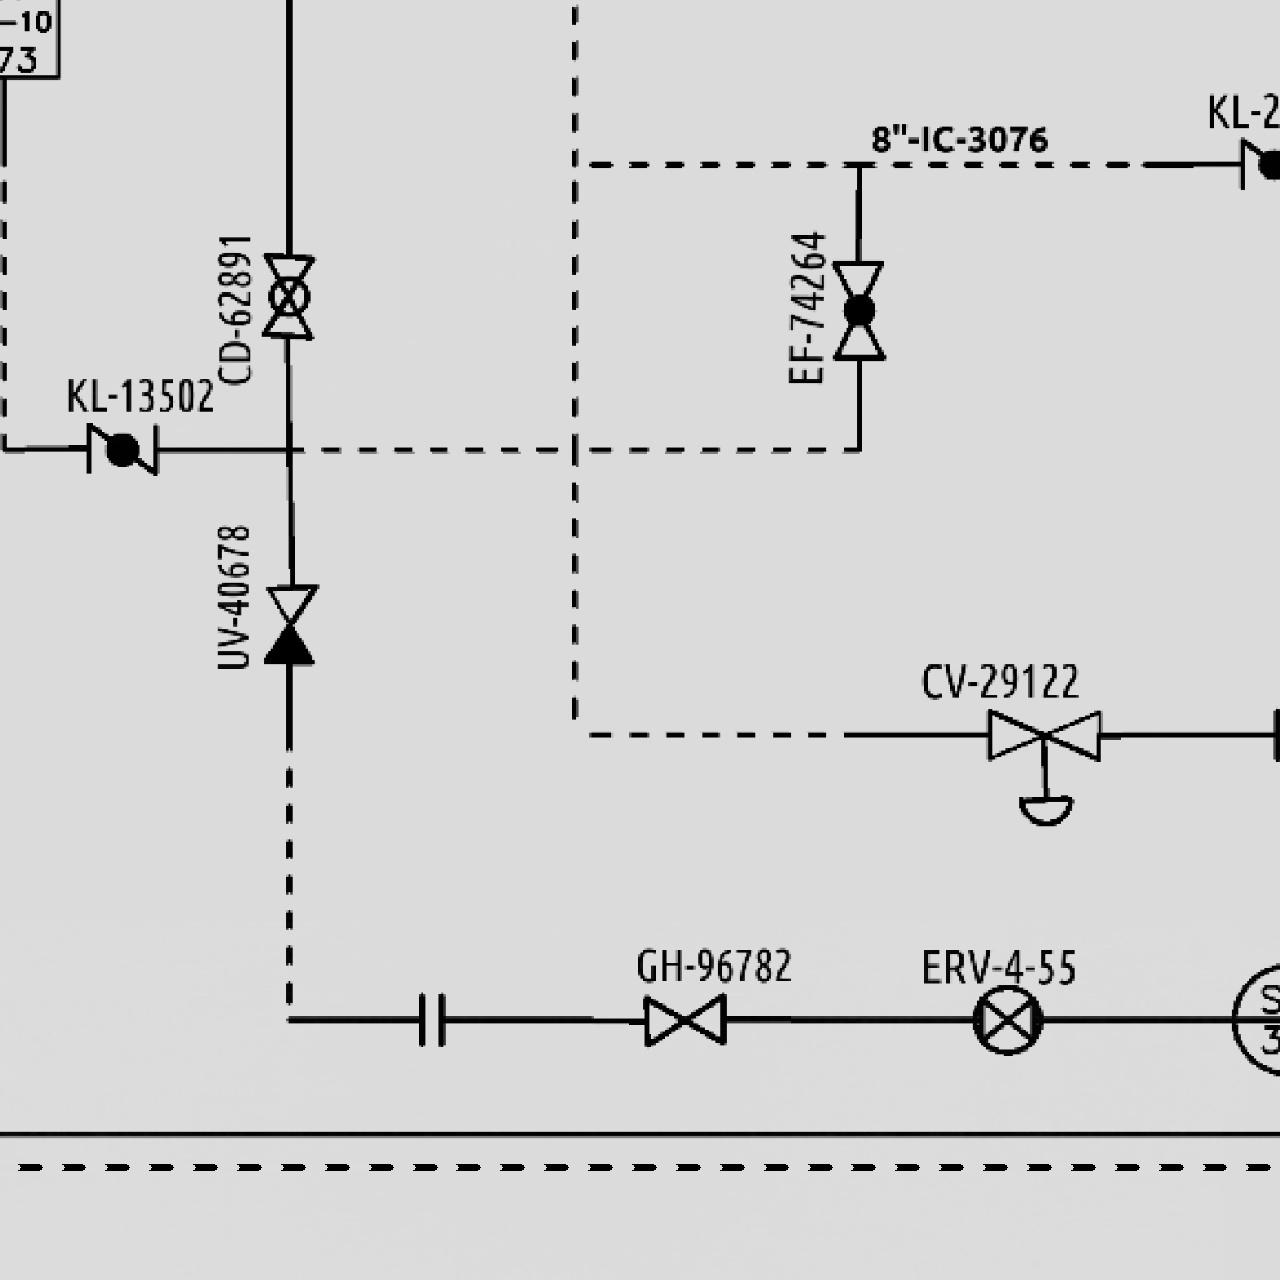

In [25]:
sample_stems = list(unannotated_but_listed)[:5]
print("Sample stems flagged as real mismatch:", sample_stems)

# Check the raw train.txt/val.txt lines for one of these to rule out a path-format bug
for lst in ('train.txt', 'val.txt'):
    f = kaggle_p / lst
    if f.exists():
        matches = [l for l in f.read_text().splitlines() if Path(l.strip()).stem in sample_stems]
        print(f"{lst}: {matches[:3]}")

# Show one flagged image at full size to visually check if it looks like a blank/background tile
from PIL import Image
img_path = next(p for p in (kaggle_p / "images").glob("*.jpg") if p.stem == sample_stems[0])
print("Opening:", img_path)
display(Image.open(img_path))

## 6c. Re-download Kaggle P&ID Symbols and compare (investigating 1.5 label gap)

Current Drive copy has labels for only ~22% of its images (6,591/30,000), vs the ~195k-
instance dataset card. Re-download fresh into a separate temp folder first — don't
overwrite the existing copy until we confirm the new download is actually more complete.

In [27]:
KAGGLE_REDL_DIR = Path(DRIVE_ROOT) / "kaggle_pid_symbols_redownload"
KAGGLE_REDL_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d hristohristov21/pid-symbols -p "{KAGGLE_REDL_DIR}" --unzip

redl_scan = scan_tree(KAGGLE_REDL_DIR)
print("\nRe-downloaded copy:")
print("  images:", redl_scan['n_images'])
print("  label .txt files:", len(redl_scan['label_txt_files']))

redl_counts = yolo_class_histogram(redl_scan['label_txt_files']) if redl_scan['label_txt_files'] else Counter()
print("  total instances:", sum(redl_counts.values()))
print("  classes represented:", len(redl_counts))

print("\n--- Comparison ---")
print(f"  existing copy:      {scan_tree(kaggle_p)['n_images']} images, {len(list((kaggle_p/'labels').glob('*.txt')))} labels")
print(f"  re-downloaded copy: {redl_scan['n_images']} images, {len(redl_scan['label_txt_files'])} labels")

Dataset URL: https://www.kaggle.com/datasets/hristohristov21/pid-symbols
License(s): other
100% 1.41G/1.41G [01:14<00:00, 20.3MB/s]


Re-downloaded copy:
  images: 30000
  label .txt files: 0
  total instances: 0
  classes represented: 0

--- Comparison ---
  existing copy:      30000 images, 6591 labels
  re-downloaded copy: 30000 images, 0 labels


In [29]:
all_txt = list(KAGGLE_REDL_DIR.rglob('*.txt'))
print(f"Total .txt files anywhere in re-download: {len(all_txt)}")
print("Sample:", [str(p.relative_to(KAGGLE_REDL_DIR)) for p in all_txt[:10]])

# top-level structure
for p in sorted(KAGGLE_REDL_DIR.iterdir()):
    print(p.name, "/" if p.is_dir() else "")

Total .txt files anywhere in re-download: 30002
Sample: ['train (2).txt', 'val (1).txt', 'labels (2)/0_0_0.txt', 'labels (2)/0_0_1280.txt', 'labels (2)/0_0_1920.txt', 'labels (2)/0_0_2560.txt', 'labels (2)/0_0_3200.txt', 'labels (2)/0_0_3840.txt', 'labels (2)/0_0_4480.txt', 'labels (2)/0_0_5120.txt']
images (3) /
labels (2) /
train (2).txt 
val (1).txt 


In [30]:
redl_labels = list((KAGGLE_REDL_DIR / "labels (2)").glob("*.txt"))
print("Label files:", len(redl_labels))

redl_counts = yolo_class_histogram(redl_labels)
print("Total instances:", sum(redl_counts.values()))
print("Classes represented:", len(redl_counts))

Label files: 30000
Total instances: 195759
Classes represented: 32


## 6d. Swap in the fixed Kaggle copy

Re-downloaded copy confirmed complete: 30,000/30,000 labeled, 195,759 instances, 32 classes
— matches the dataset card. The original `kaggle_pid_symbols/` was a broken/incomplete
upload (only 6,591/30,000 labeled). Deleting the broken copy and promoting the fresh one
in its place.

**Destructive — deletes `kaggle_pid_symbols/` permanently.** Only run after confirming
the numbers above look right.

In [31]:
import shutil

assert sum(yolo_class_histogram(list((KAGGLE_REDL_DIR / 'labels (2)').glob('*.txt'))).values()) > 190_000, \
    "Sanity check failed — re-downloaded copy doesn't look complete. Stopping before delete."

shutil.rmtree(kaggle_p)
print("Deleted broken copy:", kaggle_p)

# normalize the Drive-suffixed names before renaming into place
(KAGGLE_REDL_DIR / "labels (2)").rename(KAGGLE_REDL_DIR / "labels")
(KAGGLE_REDL_DIR / "images (3)").rename(KAGGLE_REDL_DIR / "images")
(KAGGLE_REDL_DIR / "train (2).txt").rename(KAGGLE_REDL_DIR / "train.txt")
(KAGGLE_REDL_DIR / "val (1).txt").rename(KAGGLE_REDL_DIR / "val.txt")

KAGGLE_REDL_DIR.rename(kaggle_p)
print("Promoted fixed copy to:", kaggle_p)

# re-verify in place
final_scan = scan_tree(kaggle_p)
final_counts = yolo_class_histogram(final_scan['label_txt_files'])
print(f"\nFinal check — images: {final_scan['n_images']}, labels: {len(final_scan['label_txt_files'])}, "
      f"instances: {sum(final_counts.values())}, classes: {len(final_counts)}")

Deleted broken copy: /content/drive/MyDrive/pid_project/data/kaggle_pid_symbols
Promoted fixed copy to: /content/drive/MyDrive/pid_project/data/kaggle_pid_symbols

Final check — images: 30000, labels: 30000, instances: 195759, classes: 32


## 7. Summary manifest (for the benchmarking repo)

Writes a small JSON manifest back to Drive so `experiments/v1.md` can reference the exact
data state this run saw (spec: every experiment records its data version).

In [22]:
manifest = {
    "data_version": DATA_VERSION,
    "drive_root": str(ROOT),
    "datasets": {
        "kaggle":    {"present": kaggle_ok, "images": scan_tree(kaggle_p)['n_images'] if kaggle_ok else 0},
        "gupta":     {"present": gupta_ok,  "images": scan_tree(gupta_p / 'PID_Dataset' / '0__raw_data')['n_images'] if gupta_ok  else 0},
        "pid2graph": {"present": p2g_ok,    "images": scan_tree(p2g_p)['n_images']    if p2g_ok    else 0},
    },
}
out = ROOT / f"manifest_{DATA_VERSION}.json"
out.write_text(json.dumps(manifest, indent=2))
print("Wrote", out)
print(json.dumps(manifest, indent=2))

Wrote /content/drive/MyDrive/pid_project/data/manifest_data-v1.json
{
  "data_version": "data-v1",
  "drive_root": "/content/drive/MyDrive/pid_project/data",
  "datasets": {
    "kaggle": {
      "present": true,
      "images": 30000
    },
    "gupta": {
      "present": true,
      "images": 92
    },
    "pid2graph": {
      "present": true,
      "images": 33685
    }
  }
}


## 6e. Visual spot-check (Checklist 1.6)

Render 5 Gupta + 5 Kaggle images with boxes overlaid to confirm boxes actually land on
symbols — catches xywh/xyxy and normalized/absolute coordinate bugs that pure counting
can't. Auto-detects normalized vs. absolute coords by checking value ranges. Saves 10
overlay PNGs to Drive.

In [ ]:
from PIL import ImageDraw
import random
random.seed(0)

OVERLAY_DIR = Path(DRIVE_ROOT) / "overlays"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

def parse_yolo_line(line, img_w, img_h):
    """Returns (cls, x0, y0, x1, y1) in absolute pixel coords. Auto-detects normalized
    (0-1) vs. absolute coords, and cxcywh vs. xyxy, from value ranges."""
    parts = line.split()
    cls = parts[0]
    a, b, c, d = (float(v) for v in parts[1:5])
    normalized = max(a, b, c, d) <= 1.0
    if normalized:
        a, b, c, d = a * img_w, b * img_h, c * img_w, d * img_h
    # assume cxcywh (standard YOLO); if c,d look like a second coordinate rather than a
    # size (i.e. c < a or d < b, impossible for a width/height), treat as xyxy instead
    if c < a or d < b:
        x0, y0, x1, y1 = a, b, c, d
    else:
        x0, y0, x1, y1 = a - c / 2, b - d / 2, a + c / 2, b + d / 2
    return cls, x0, y0, x1, y1

def render_overlay(img_path, label_path, out_path, title):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    n_boxes = 0
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            cls, x0, y0, x1, y1 = parse_yolo_line(line, img.width, img.height)
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            draw.text((x0 + 2, max(0, y0 - 12)), cls, fill="red")
            n_boxes += 1
    img.save(out_path)
    print(f"{title}: {n_boxes} boxes -> {out_path}")
    display(img.resize((min(600, img.width), int(img.height * min(600, img.width) / img.width))))

# --- Kaggle: 5 random labeled tiles ---
if kaggle_ok:
    kaggle_labels = list((kaggle_p / "labels").glob("*.txt"))
    for i, lbl in enumerate(random.sample(kaggle_labels, 5)):
        img_path = kaggle_p / "images" / f"{lbl.stem}.jpg"
        render_overlay(img_path, lbl, OVERLAY_DIR / f"kaggle_{i}_{lbl.stem}.png", f"KAGGLE[{i}]")

# --- Gupta: 5 random sheets (mix of train/test) ---
if gupta_ok:
    raw = gupta_p / "PID_Dataset" / "0__raw_data"
    gupta_pairs = []
    for split in ('train', 'test'):
        for lbl in (raw / "labels" / split).glob("*.txt"):
            img_candidates = list((raw / "sheets" / split).glob(f"{lbl.stem}.*"))
            if img_candidates:
                gupta_pairs.append((img_candidates[0], lbl))
    for i, (img_path, lbl) in enumerate(random.sample(gupta_pairs, 5)):
        render_overlay(img_path, lbl, OVERLAY_DIR / f"gupta_{i}_{lbl.stem}.png", f"GUPTA[{i}]")

print(f"\nSaved 10 overlays to {OVERLAY_DIR}")

## What to report back to me

After running, tell me:
1. The **presence check** (§2) results — which datasets are ✅.
2. The **Kaggle class distribution** (§4) — especially the rarest classes.
3. Whether **Gupta confirmed class-agnostic** labelling (§5), and the split folder counts.
4. Any **unreadable images** or extreme size ranges (§6).

That tells us whether the data is clean enough to proceed, and it feeds the
fixed-head-vs-Siamese decision before we touch **Step 3 (baseline)**.